In [1]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

In [2]:
import zipfile

In [3]:
data_dir = "PRCP-1001-RiceLeaf.zip"

In [4]:
print("Dataset exists:", os.path.exists(data_dir))

Dataset exists: True


In [5]:
with zipfile.ZipFile(data_dir, "r") as zip_ref:
    zip_ref.extractall("RiceLeaf")

In [6]:
with zipfile.ZipFile("RiceLeaf/Data/Bacterial leaf blight-20200814T055237Z-001.zip", "r") as zip_ref:
    zip_ref.extractall("RiceLeaf/Data/Bacterial leaf blight")

In [7]:
with zipfile.ZipFile("RiceLeaf/Data/Brown spot-20200814T055208Z-001.zip", "r") as zip_ref:
    zip_ref.extractall("RiceLeaf/Data/Brown spot")

In [8]:
with zipfile.ZipFile("RiceLeaf/Data/Leaf smut-20200814T055530Z-001.zip", "r") as zip_ref:
    zip_ref.extractall("RiceLeaf/Data/Leaf smut")

In [9]:
data_dir = "RiceLeaf/Data"

In [10]:
class_names = os.listdir(data_dir)
print(class_names)

['Bacterial leaf blight', 'Bacterial leaf blight-20200814T055237Z-001.zip', 'Brown spot', 'Brown spot-20200814T055208Z-001.zip', 'Leaf smut', 'Leaf smut-20200814T055530Z-001.zip']


In [11]:
print(os.listdir("RiceLeaf/Data/Bacterial leaf blight")[:5])

['Bacterial leaf blight', 'DSC_0365.JPG', 'DSC_0366.jpg', 'DSC_0367.JPG', 'DSC_0370.jpg']


In [12]:
print(os.listdir("RiceLeaf/Data/Bacterial leaf blight/Bacterial leaf blight")[:10])

['DSC_0365.JPG', 'DSC_0366.jpg', 'DSC_0367.JPG', 'DSC_0370.jpg', 'DSC_0372.JPG', 'DSC_0373.JPG', 'DSC_0374.JPG', 'DSC_0375.JPG', 'DSC_0376.JPG', 'DSC_0377.JPG']


In [13]:
import os
os.remove("RiceLeaf/Data/Bacterial leaf blight-20200814T055237Z-001.zip")
os.remove("RiceLeaf/Data/Brown spot-20200814T055208Z-001.zip")
os.remove("RiceLeaf/Data/Leaf smut-20200814T055530Z-001.zip")

print("ZIP files deleted.")

ZIP files deleted.


In [14]:
class_names = os.listdir(data_dir)
print(class_names)

['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [15]:
print("Number of classes:", len(class_names))

Number of classes: 3


In [16]:
for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    image_count = len(os.listdir(class_path))
    print(f"{class_name}: {image_count} images")

Bacterial leaf blight: 41 images
Brown spot: 41 images
Leaf smut: 40 images


In [17]:
import os
import shutil
data_dir = "RiceLeaf/data"
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    nested_path = os.path.join(class_path, class_name)
    if os.path.isdir(nested_path):
        for image in os.listdir(nested_path):
            source = os.path.join(nested_path, image)
            destination = os.path.join(class_path, image)
            shutil.move(source, destination)
        os.rmdir(nested_path)
print("Extra nested folders removed")

Extra nested folders removed


In [18]:
# Counting the number of images in each class
for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    image_count = len(os.listdir(class_path))
    print(f"{class_name}: {image_count} images")

Bacterial leaf blight: 40 images
Brown spot: 40 images
Leaf smut: 39 images


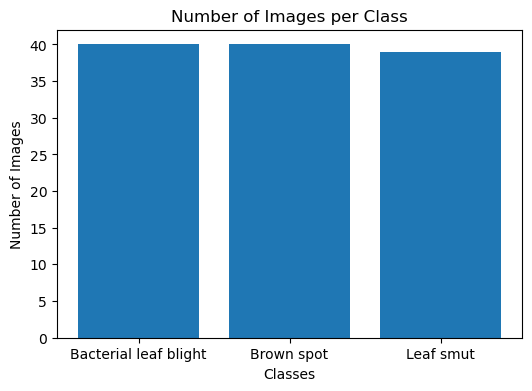

In [19]:
# Plotting the class distribution
image_counts = []

for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    image_counts.append(len(os.listdir(class_path)))

plt.figure(figsize=(6,4))
plt.bar(class_names, image_counts)
plt.title("Number of Images per Class")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

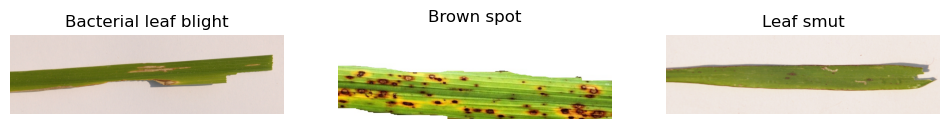

In [20]:
# Displaying sample images from each class
from PIL import Image
plt.figure(figsize=(12,4))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(data_dir, class_name)
    image_path = os.path.join(class_path, os.listdir(class_path)[0])

    image = Image.open(image_path)

    plt.subplot(1,3,i+1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [21]:
# Checking image size
image = Image.open(image_path)
print(image.size)

(3081, 897)


In [22]:
# checking image mode
print(image.mode)

RGB


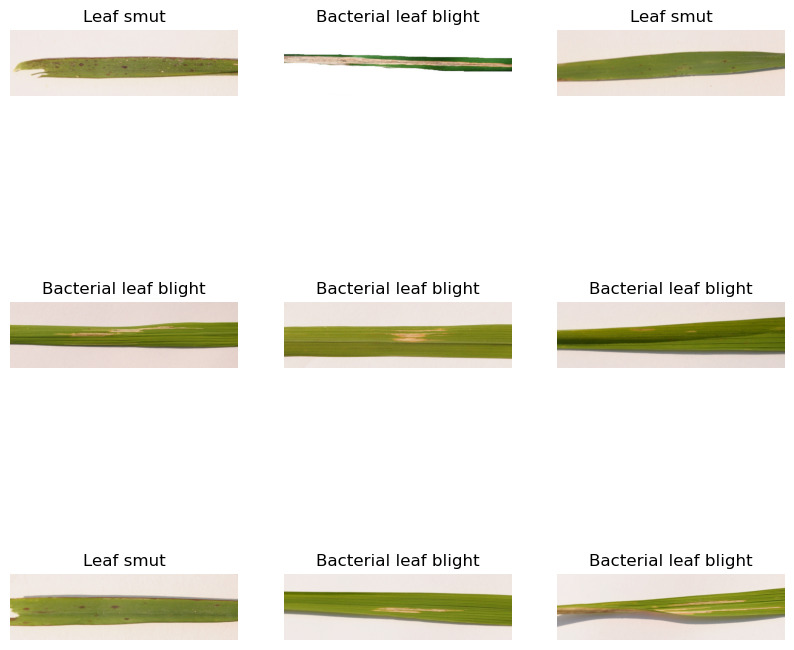

In [23]:
# Displaying multiple random images
plt.figure(figsize=(10,10))

for i in range(9):
    class_name = np.random.choice(class_names)
    class_path = os.path.join(data_dir, class_name)

    image_name = np.random.choice(os.listdir(class_path))
    image = Image.open(os.path.join(class_path, image_name))

    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [24]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training",
    seed=42, image_size=(224,224), batch_size=8
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation",
    seed=42, image_size=(224,224), batch_size=8
)

Found 119 files belonging to 3 classes.
Using 96 files for training.
Found 119 files belonging to 3 classes.
Using 23 files for validation.


In [25]:
class_names = train_ds.class_names   
print(class_names)

['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [26]:
from tensorflow.keras import models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
], name="data_augmentation")

In [27]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

In [28]:
from sklearn.utils.class_weight import compute_class_weight

# Extract all labels from train_ds to compute class weights
train_labels = np.concatenate([labels for _, labels in train_ds])

class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight = dict(enumerate(class_weight_values))

print("Class weights:", class_weight)

Class weights: {0: np.float64(0.9696969696969697), 1: np.float64(0.9142857142857143), 2: np.float64(1.1428571428571428)}


#  MobileNetV2 model

In [29]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from sklearn.metrics import classification_report, confusion_matrix
 

In [30]:
num_classes = len(class_names)

In [31]:
mobilenet_base = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
mobilenet_base.trainable = False  # Stage 1: freeze base
 
mobilenet_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Lambda(mobilenet_preprocess, name="mobilenet_preprocessing"), 
    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
], name="MobileNetV2_RiceLeaf")

In [32]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
mobilenet_model.summary()

Model: "MobileNetV2_RiceLeaf"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocessing         │ (None, 224, 224, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,163 (8.93 MB)

 Trainable params: 82,179 (321.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [34]:
mobilenet_early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
mobilenet_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7)
 
mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[mobilenet_early_stop, mobilenet_reduce_lr],
    class_weight=class_weight
)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 24s 891ms/step - accuracy: 0.4583 - loss: 1.3140 - val_accuracy: 0.5217 - val_loss: 0.8847 - learning_rate: 0.0010
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 504ms/step - accuracy: 0.7292 - loss: 0.7330 - val_accuracy: 0.8261 - val_loss: 0.4838 - learning_rate: 0.0010
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 531ms/step - accuracy: 0.7917 - loss: 0.5281 - val_accuracy: 0.6087 - val_loss: 0.7112 - learning_rate: 0.0010
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 508ms/step - accuracy: 0.8438 - loss: 0.4373 - val_accuracy: 0.6957 - val_loss: 0.4452 - learning_rate: 0.0010
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 481ms/step - accuracy: 0.8646 - loss: 0.3422 - val_accuracy: 0.7391 - val_loss: 0.4167 - learning_rate: 0.0010
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 556ms/step - accuracy: 0.9167 - loss: 0.2933 - val_accuracy: 0.7391 - val_loss: 0.4745 - learning_rate: 0.0010
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 469ms/step - accuracy: 0.8854 - loss: 0.2866 

In [35]:
# FIT — Stage 2: fine-tune top layers of the base model

mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False
 
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
 
mobilenet_finetune_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[mobilenet_early_stop, mobilenet_reduce_lr],
    class_weight=class_weight
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 854ms/step - accuracy: 0.5833 - loss: 0.9319 - val_accuracy: 0.8261 - val_loss: 0.4814 - learning_rate: 1.0000e-05
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 555ms/step - accuracy: 0.6354 - loss: 0.9131 - val_accuracy: 0.7826 - val_loss: 0.4811 - learning_rate: 1.0000e-05
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 587ms/step - accuracy: 0.5938 - loss: 0.7815 - val_accuracy: 0.7826 - val_loss: 0.4801 - learning_rate: 1.0000e-05
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 542ms/step - accuracy: 0.7188 - loss: 0.7218 - val_accuracy: 0.7826 - val_loss: 0.4788 - learning_rate: 1.0000e-05
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 614ms/step - accuracy: 0.6771 - loss: 0.7707 - val_accuracy: 0.7826 - val_loss: 0.4776 - learning_rate: 1.0000e-05
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 838ms/step - accuracy: 0.6875 - loss: 0.7104 - val_accuracy: 0.7826 - val_loss: 0.4796 - learning_rate: 1.0000e-05
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 993ms/step - accurac

In [36]:
final_val_acc = mobilenet_finetune_history.history['val_accuracy'][-1]
final_val_loss = mobilenet_finetune_history.history['val_loss'][-1]

print("Final Validation Accuracy:", final_val_acc)
print("Final Validation Loss:", final_val_loss)

Final Validation Accuracy: 0.6521739363670349
Final Validation Loss: 0.48537805676460266


In [37]:
def plot_history(history, title_prefix):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)
 
    plt.figure(figsize=(12, 5))
 
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title_prefix}: Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
 
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title_prefix}: Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()
 
 

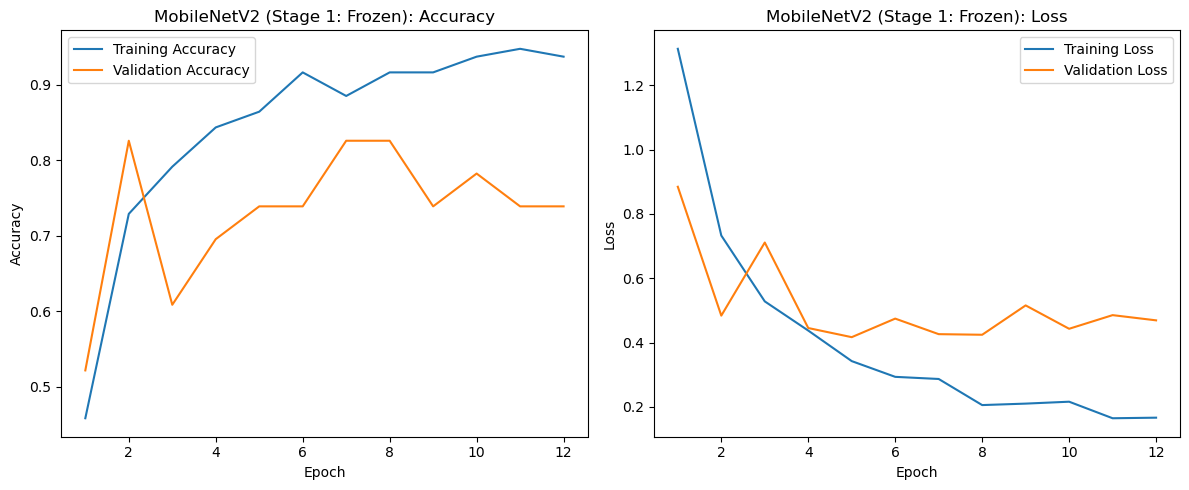

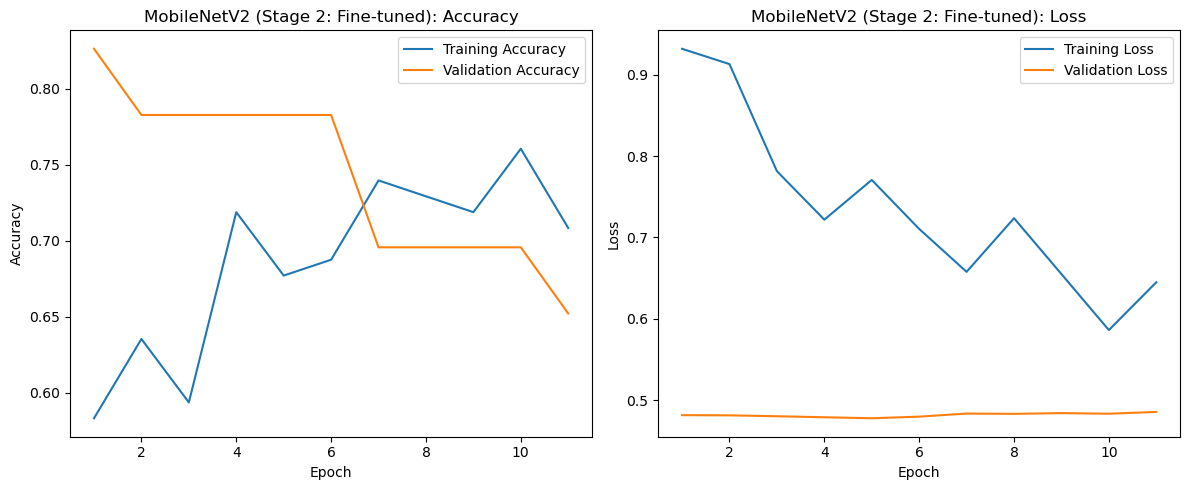

In [38]:
plot_history(mobilenet_history, "MobileNetV2 (Stage 1: Frozen)")
plot_history(mobilenet_finetune_history, "MobileNetV2 (Stage 2: Fine-tuned)")

In [39]:
mn_y_pred_probs = mobilenet_model.predict(val_ds)
mn_y_pred = np.argmax(mn_y_pred_probs, axis=1)
mn_y_true = np.concatenate([labels for _, labels in val_ds])

3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step   



MobileNetV2 Classification Report:

                       precision    recall  f1-score   support

Bacterial leaf blight       0.88      1.00      0.93         7
           Brown spot       0.75      0.60      0.67         5
            Leaf smut       0.82      0.82      0.82        11

             accuracy                           0.83        23
            macro avg       0.81      0.81      0.81        23
         weighted avg       0.82      0.83      0.82        23



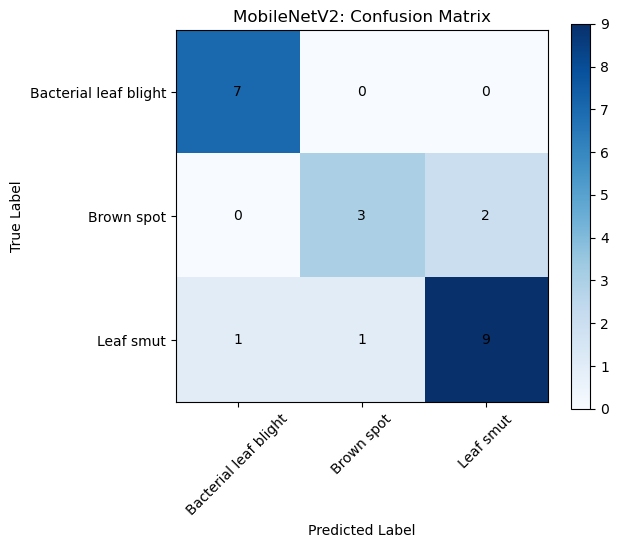

In [40]:
print("\nMobileNetV2 Classification Report:\n")
print(classification_report(mn_y_true, mn_y_pred, target_names=class_names))
 
cm = confusion_matrix(mn_y_true, mn_y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title('MobileNetV2: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.colorbar()
plt.show()
 

In [41]:
from tensorflow.keras.preprocessing import image

img_path = "rice_image.jfif"
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = mobilenet_model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Disease :", predicted_class)
print("Prediction Probabilities :", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Predicted Disease : Brown spot
Prediction Probabilities : [[0.1174321  0.5861111  0.29645678]]


# EfficientNet Model

In [42]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

In [43]:
efficientnet_base = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
efficientnet_base.trainable = False  # Stage 1: freeze base
 
efficientnet_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Lambda(efficientnet_preprocess, name="efficientnet_preprocessing"),
    efficientnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
], name="EfficientNetB0_RiceLeaf")

In [44]:
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
efficientnet_model.summary()

Model: "EfficientNetB0_RiceLeaf"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_preprocessing      │ (None, 224, 224, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,131,750 (15.76 MB)

 Trainable params: 82,179 (321.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [46]:
 # Fit Stage 1: frozen base
efficientnet_early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
efficientnet_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7)
 
efficientnet_history = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[efficientnet_early_stop, efficientnet_reduce_lr],
    class_weight=class_weight
)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.4271 - loss: 1.1654 - val_accuracy: 0.7826 - val_loss: 0.7516 - learning_rate: 0.0010
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 635ms/step - accuracy: 0.6875 - loss: 0.7691 - val_accuracy: 0.8261 - val_loss: 0.6223 - learning_rate: 0.0010
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 624ms/step - accuracy: 0.8229 - loss: 0.5792 - val_accuracy: 0.7826 - val_loss: 0.4423 - learning_rate: 0.0010
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 684ms/step - accuracy: 0.8125 - loss: 0.4728 - val_accuracy: 0.9130 - val_loss: 0.3812 - learning_rate: 0.0010
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 602ms/step - accuracy: 0.8646 - loss: 0.3205 - val_accuracy: 0.8261 - val_loss: 0.4347 - learning_rate: 0.0010
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 630ms/step - accuracy: 0.8646 - loss: 0.3878 - val_accuracy: 0.9130 - val_loss: 0.3087 - learning_rate: 0.0010
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 638ms/step - accuracy: 0.9167 - loss: 0.2516 - v

In [47]:
 
#  Fit Stage 2: fine-tune top layer
efficientnet_base.trainable = True
for layer in efficientnet_base.layers[:-30]:
    layer.trainable = False
 
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
 

In [48]:
efficientnet_finetune_history = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[efficientnet_early_stop, efficientnet_reduce_lr],
    class_weight=class_weight
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.7500 - loss: 0.6351 - val_accuracy: 0.9130 - val_loss: 0.2032 - learning_rate: 1.0000e-05
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 907ms/step - accuracy: 0.7604 - loss: 0.5461 - val_accuracy: 0.9130 - val_loss: 0.2196 - learning_rate: 1.0000e-05
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 879ms/step - accuracy: 0.8021 - loss: 0.5546 - val_accuracy: 0.9130 - val_loss: 0.2354 - learning_rate: 1.0000e-05
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 850ms/step - accuracy: 0.7917 - loss: 0.5777 - val_accuracy: 0.8696 - val_loss: 0.2531 - learning_rate: 1.0000e-05
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 801ms/step - accuracy: 0.7604 - loss: 0.5647 - val_accuracy: 0.8696 - val_loss: 0.2663 - learning_rate: 1.0000e-05
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 805ms/step - accuracy: 0.8333 - loss: 0.5188 - val_accuracy: 0.8696 - val_loss: 0.2865 - learning_rate: 5.0000e-06
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 746ms/step - accura

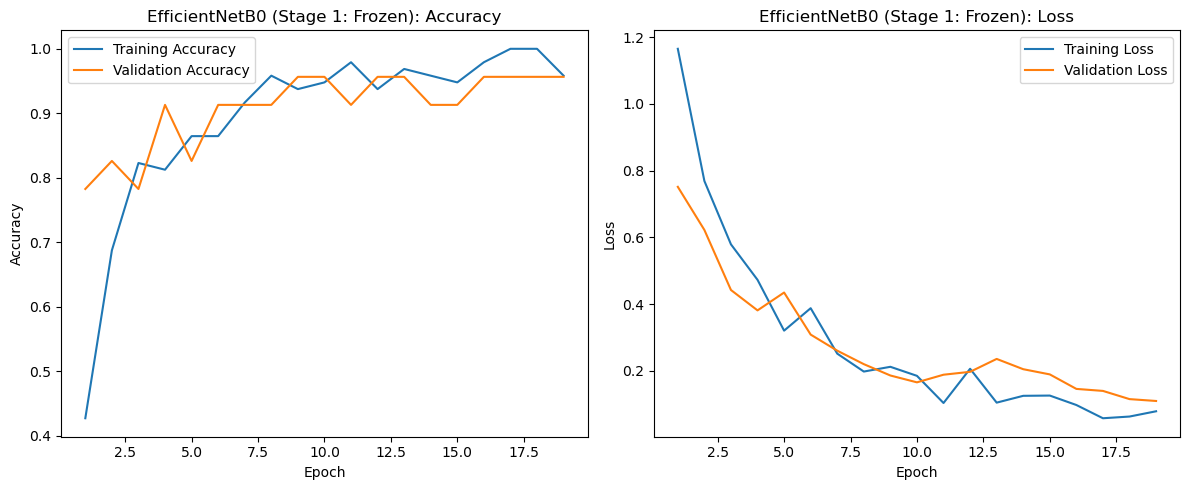

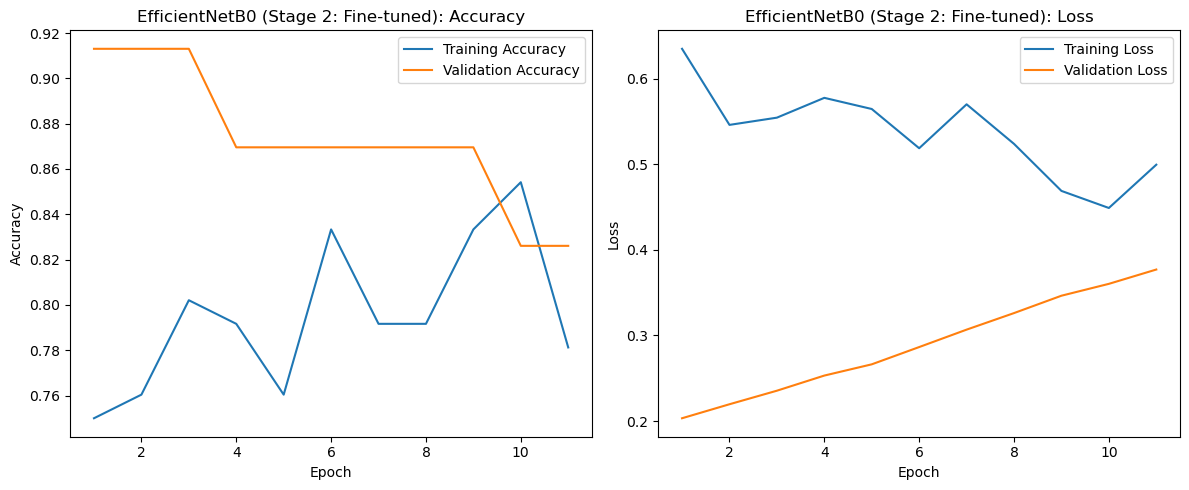

In [49]:
plot_history(efficientnet_history, "EfficientNetB0 (Stage 1: Frozen)")
plot_history(efficientnet_finetune_history, "EfficientNetB0 (Stage 2: Fine-tuned)")

In [50]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Collect image paths and labels
filepaths = []
labels = []
for idx, class_name in enumerate(class_names):
    class_path = os.path.join(data_dir, class_name)
    for fname in os.listdir(class_path):
        filepaths.append(os.path.join(class_path, fname))
        labels.append(idx)

# Load all images into memory
images = np.array([img_to_array(load_img(p, target_size=(224, 224))) for p in filepaths])
labels = np.array(labels)

# 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []

for fold, (train_idx, val_idx) in enumerate(skf.split(images, labels)):
    X_train, X_val = images[train_idx], images[val_idx]
    y_train, y_val = labels[train_idx], labels[val_idx]

    base = EfficientNetB0(input_shape=(224,224,3), include_top=False, weights='imagenet')
    base.trainable = False

    model = models.Sequential([
        layers.Input(shape=(224,224,3)),
        layers.Lambda(efficientnet_preprocess),
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, verbose=0)

    loss, acc = model.evaluate(X_val, y_val, verbose=0)
    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    accuracies.append(acc)

print(f"\nMean Accuracy: {np.mean(accuracies):.4f}")

Fold 1 Accuracy: 0.9167
Fold 2 Accuracy: 0.6667
Fold 3 Accuracy: 0.8750
Fold 4 Accuracy: 0.8333
Fold 5 Accuracy: 0.7391

Mean Accuracy: 0.8062


In [51]:
def evaluate_model(model, val_ds, class_names, title_prefix):
    """Runs evaluate(), classification_report(), and confusion matrix."""
    loss, accuracy = model.evaluate(val_ds)
    print(f"\n{title_prefix} Validation Loss     : {loss:.4f}")
    print(f"{title_prefix} Validation Accuracy : {accuracy:.4f}")

    y_pred_probs = model.predict(val_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.concatenate([labels for _, labels in val_ds])

    print(f"\n{title_prefix} Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap='Blues')
    plt.title(f'{title_prefix}: Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
    plt.yticks(np.arange(len(class_names)), class_names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
    plt.colorbar()
    plt.show()

    return loss, accuracy, y_true, y_pred

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 450ms/step - accuracy: 0.9130 - loss: 0.2032

EfficientNetB0 Validation Loss     : 0.2032
EfficientNetB0 Validation Accuracy : 0.9130
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step  

EfficientNetB0 Classification Report:

                       precision    recall  f1-score   support

Bacterial leaf blight       0.88      1.00      0.93         7
           Brown spot       0.83      1.00      0.91         5
            Leaf smut       1.00      0.82      0.90        11

             accuracy                           0.91        23
            macro avg       0.90      0.94      0.91        23
         weighted avg       0.93      0.91      0.91        23



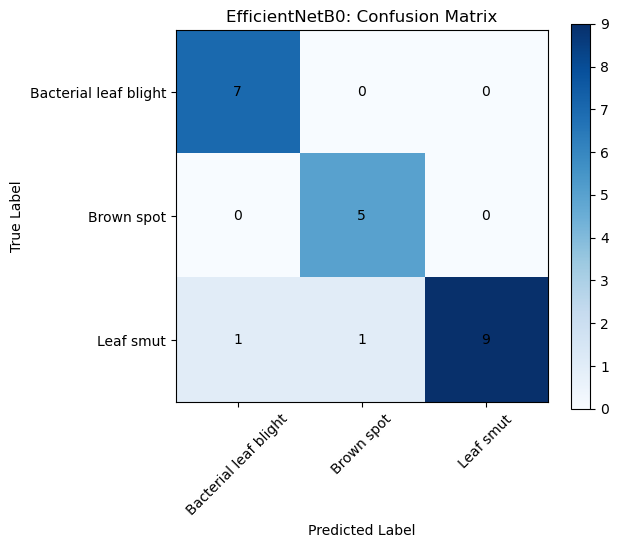

In [52]:
efficientnet_loss, efficientnet_acc, en_y_true, en_y_pred = evaluate_model(
    efficientnet_model, val_ds, class_names, "EfficientNetB0"
)

In [53]:
# predicting single image
from tensorflow.keras.preprocessing import image

img_path = "rice_image.jfif"  

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = efficientnet_model.predict(img_array) 
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Disease :", predicted_class)
print("Prediction Probabilities :", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Predicted Disease : Brown spot
Prediction Probabilities : [[0.0472183 0.6939364 0.2588453]]


# Model comparison

In [54]:
import pandas as pd
from sklearn.metrics import classification_report
mn_report = classification_report(mn_y_true, mn_y_pred, target_names=class_names, output_dict=True)
en_report = classification_report(en_y_true, en_y_pred, target_names=class_names, output_dict=True)

mn_y_pred_probs = mobilenet_model.predict(val_ds)
mn_y_pred = np.argmax(mn_y_pred_probs, axis=1)
mn_y_true = np.concatenate([labels for _, labels in val_ds])

en_y_pred_probs = efficientnet_model.predict(val_ds)
en_y_pred = np.argmax(en_y_pred_probs, axis=1)
en_y_true = np.concatenate([labels for _, labels in val_ds])


print("=" * 70)
print("MobileNetV2 Classification Report")
print("=" * 70)
print(classification_report(mn_y_true, mn_y_pred, target_names=class_names))

print("=" * 70)
print("EfficientNetB0 Classification Report")
print("=" * 70)
print(classification_report(en_y_true, en_y_pred, target_names=class_names))


print(f"\nMobileNetV2 Overall Accuracy    : {mn_report['accuracy']:.4f}")
print(f"EfficientNetB0 Overall Accuracy : {en_report['accuracy']:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 356ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 447ms/step
MobileNetV2 Classification Report
                       precision    recall  f1-score   support

Bacterial leaf blight       0.88      1.00      0.93         7
           Brown spot       0.75      0.60      0.67         5
            Leaf smut       0.82      0.82      0.82        11

             accuracy                           0.83        23
            macro avg       0.81      0.81      0.81        23
         weighted avg       0.82      0.83      0.82        23

EfficientNetB0 Classification Report
                       precision    recall  f1-score   support

Bacterial leaf blight       0.88      1.00      0.93         7
           Brown spot       0.83      1.00      0.91         5
            Leaf smut       1.00      0.82      0.90        11

             accuracy                           0.91        23
            macro avg       0.90      0.94      0.91        23
         weighted avg      

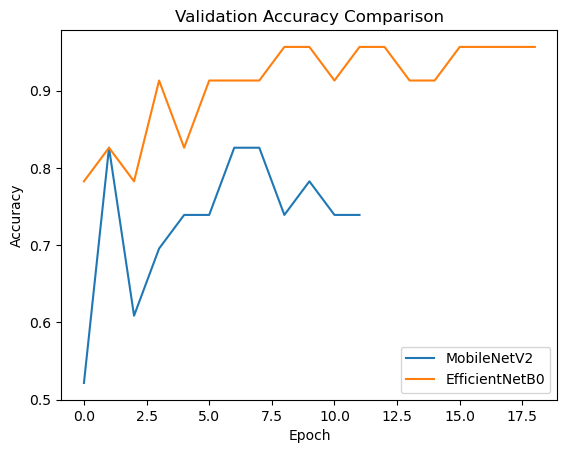

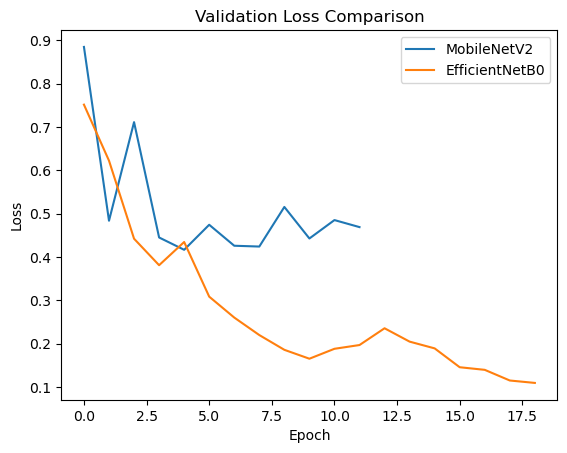

In [55]:
import matplotlib.pyplot as plt

# Validation Accuracy comparison
plt.plot(mobilenet_history.history['val_accuracy'], label='MobileNetV2')
plt.plot(efficientnet_history.history['val_accuracy'], label='EfficientNetB0')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Validation Loss comparison
plt.plot(mobilenet_history.history['val_loss'], label='MobileNetV2')
plt.plot(efficientnet_history.history['val_loss'], label='EfficientNetB0')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Model Comparison

MobileNetV2: lightweight, stable, faster inference
EfficientNetB0: higher validation accuracy, better feature extraction on this dataset
Recommended: EfficientNetB0 — higher accuracy outweighs MobileNetV2's speed advantage for this use case

Techniques Used

1) Data augmentation (flip, rotate, zoom, contrast) — expand tiny dataset
2) Transfer learning (MobileNetV2, EfficientNetB0) — avoid training from scratch on images
3) Two-stage fine-tuning — frozen head first, then unfreeze top layers at low LR
4) Correct preprocess_input per model — avoid silent accuracy loss
5) Dropout — reduce overfitting
6) EarlyStopping + ReduceLROnPlateau — stop wisely, adapt LR
7) Class weights — handle mild class imbalance



Challenges Faced

1) Small dataset (119 images) → used transfer learning
2) Model collapse → fixed EarlyStopping patience + LR
3) BatchNorm unstable on tiny batches → reduced batch size
4) Wrong single-image predictions → fixed double preprocessing bug

